# MACHINE LEARNING PROJECT

## hospital pressure score project

The Hospital Pressure Score Dataset is a healthcare management dataset designed to analyze and predict hospital workload and operational pressure levels. It contains information about patient volume, emergency cases, bed occupancy, staff availability, and medicine usage.

The main objective of this dataset is to determine the hospital pressure level and forecast future hospital pressure scores using machine learning techniques.

### What We Did

1. Loaded and explored the dataset.
2. Cleaned and preprocessed the data.
3. Performed Exploratory Data Analysis (EDA) using graphs.
4. Created new features (Lag and Rolling features).
5. Trained and compared 5 machine learning models:

   * Logistic Regression
   * Decision Tree
   * Random Forest
   * Gradient Boosting
   * XGBoost
6. Tuned XGBoost using GridSearchCV.
7. Evaluated the model using Accuracy, Classification Report, and Confusion Matrix.
8. Forecasted the next 7 days of Hospital Pressure Score using XGBoost Regression.



In [1]:
# 1. Import Required Libraries
# In this step, we import all the Python libraries required for data analysis,
# visualization, machine learning model building, and model evaluation.

# - Pandas: Data manipulation
# - NumPy: Numerical operations
# - Matplotlib & Seaborn: Data visualization
# - Scikit-Learn: Machine learning algorithms and evaluation metrics
# - XGBoost: Advanced boosting algorithm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier, XGBRegressor

import warnings
warnings.filterwarnings("ignore")


2. Load Hospital Pressure Dataset

In [2]:
# 2. Load Hospital Pressure Dataset
# The dataset is loaded into a Pandas DataFrame for further analysis.
from pathlib import Path
possible_files = [
    "hospital_pressure_score_dataset.csv",
    "hospital_pressure_score_dataset(1).csv"
]

csv_path = None
for file in possible_files:
    if Path(file).exists():
        csv_path = file
        break

if csv_path is None:
    raise FileNotFoundError("Dataset not found. Put the CSV file in the same folder as this notebook.")

df = pd.read_csv(csv_path)
df.head()


,Date,Patients,Emergency Cases,Available Beds,Occupied Beds,Total Nurses Required,Total Doctors Required,Nurses Available,Doctors Available,Medicine Usage,Weather,Festival,Day Type,Season,Hospital Pressure Score,Pressure Level
0,2024-01-01,228,24,563,80,16,6,10,5,547,Normal,Yes,Weekday,Winter,31.49,Low
1,2024-01-02,271,41,563,90,16,8,16,8,743,Rainy,No,Weekday,Winter,32.69,Low
2,2024-01-03,274,28,563,87,15,8,15,7,712,Normal,No,Weekday,Winter,34.59,Low
3,2024-01-04,243,32,563,81,14,6,13,6,646,Normal,No,Weekday,Winter,33.54,Low
4,2024-01-05,195,24,563,80,17,6,15,5,521,Cloudy,No,Weekday,Winter,30.65,Low


3. Explore Dataset Structure
This section displays:

- Number of rows and columns
- Data types
- Missing values
- Sample records

In [3]:
print(df.shape)
df.info()

(731, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     731 non-null    object 
 1   Patients                 731 non-null    int64  
 2   Emergency Cases          731 non-null    int64  
 3   Available Beds           731 non-null    int64  
 4   Occupied Beds            731 non-null    int64  
 5   Total Nurses Required    731 non-null    int64  
 6   Total Doctors Required   731 non-null    int64  
 7   Nurses Available         731 non-null    int64  
 8   Doctors Available        731 non-null    int64  
 9   Medicine Usage           731 non-null    int64  
 10  Weather                  731 non-null    object 
 11  Festival                 731 non-null    object 
 12  Day Type                 731 non-null    object 
 13  Season                   731 non-null    object 
 14  Hospital Pressur

 4. Data Quality Check

Machine learning models cannot handle missing values properly.

In [4]:
df.isnull().sum()

Date                       0
Patients                   0
Emergency Cases            0
Available Beds             0
Occupied Beds              0
Total Nurses Required      0
Total Doctors Required     0
Nurses Available           0
Doctors Available          0
Medicine Usage             0
Weather                    0
Festival                   0
Day Type                   0
Season                     0
Hospital Pressure Score    0
Pressure Level             0
dtype: int64

5. Pressure Level Distribution Analysis

This visualization shows the distribution of hospital pressure levels.

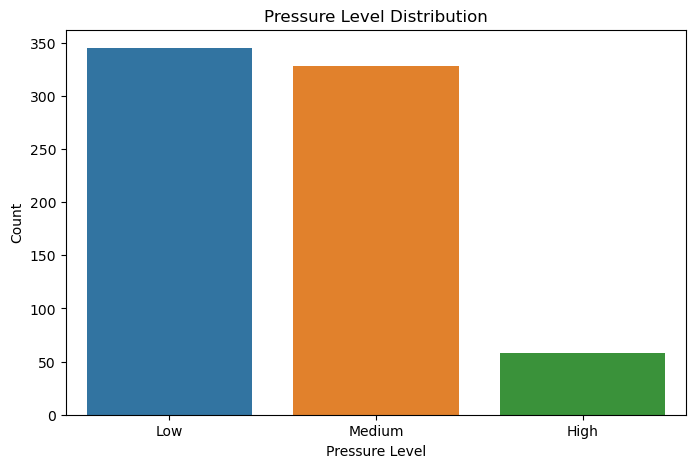

In [5]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Pressure Level"
)

plt.title("Pressure Level Distribution")
plt.xlabel("Pressure Level")
plt.ylabel("Count")
plt.show()

 6. Data Preprocessing
 - Separates features and target variables
- Removes data leakage columns

In [6]:
target = "Pressure Level"

X = df.drop(columns=[target, "Hospital Pressure Score"])
y = df[target]

for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

y = LabelEncoder().fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

8. Gradient Boosting Classifier


Gradient Boosting combines multiple weak decision trees to build a
strong predictive model.


In [7]:
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, gb_pred))

Accuracy: 0.9251700680272109


9. Extreme Gradient Boosting (XGBoost)

XGBoost is an optimized boosting algorithm widely used in machine learning competitions and industry applications.


In [8]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, xgb_pred))

Accuracy: 0.9251700680272109


 10. Confusion Matrix Evaluation

A confusion matrix provides a detailed view of model performance.

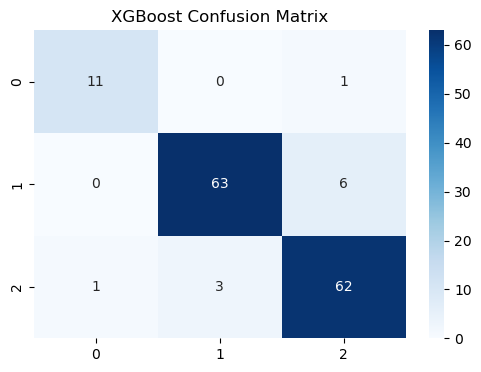

In [9]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.show()

11. Feature Importance Analysis

This graph identifies the most influential hospital factors affecting
pressure level prediction

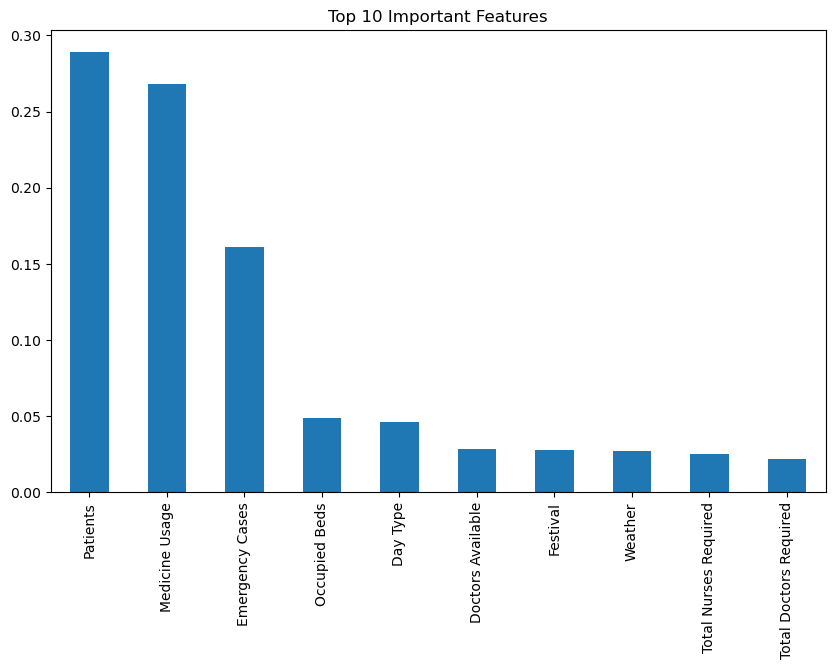

In [10]:
importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.show()

12. Correlation Analysis

The correlation heatmap shows relationships between numerical variables.

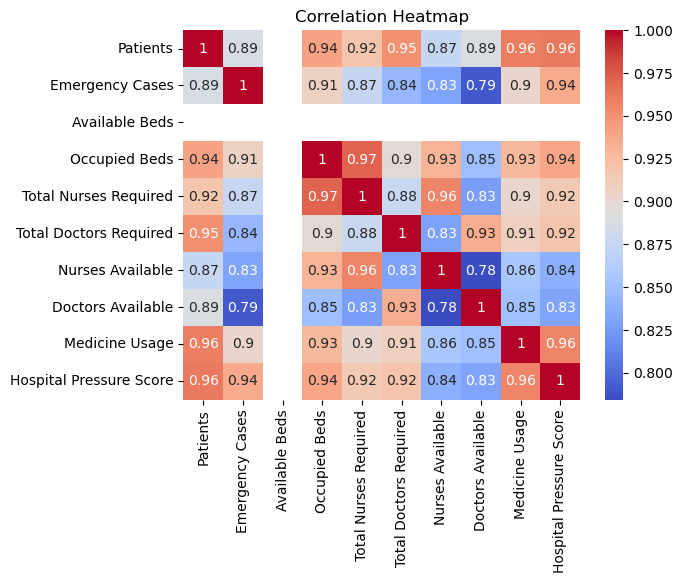

In [11]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 5. Model Comparison: 5 Machine Learning Models

This section compares five models so the project is not limited to only Gradient Boosting and XGBoost. The goal is to prove which model performs best on the hospital pressure classification task.
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. XGBoost

In [12]:
print(X_train.shape)
print(X_test.shape)

(584, 14)
(147, 14)


In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="mlogloss")
}

model_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    model_results.append({"Model": name, "Accuracy": acc})

comparison_df = pd.DataFrame(model_results).sort_values(by="Accuracy", ascending=False)
comparison_df

,Model,Accuracy
0,Logistic Regression,0.931973
2,Random Forest,0.931973
3,Gradient Boosting,0.925170
4,XGBoost,0.925170
1,Decision Tree,0.863946


14. Model Performance Visualization

This bar chart compares the accuracy of all machine learning models.

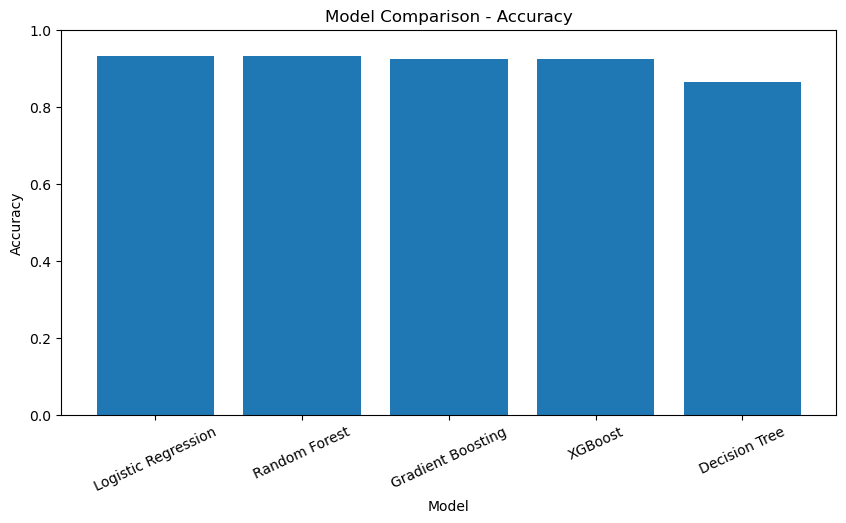

In [14]:
plt.figure(figsize=(10,5))
plt.bar(
comparison_df["Model"],
comparison_df["Accuracy"]
)
plt.title("Model Comparison - Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=25)
plt.ylim(0, 1)
plt.show()

## 6. Hyperparameter Tuning for XGBoost

Here we tune the XGBoost model using GridSearchCV. This improves the project because it shows model optimization instead of using only default settings.

In [15]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric="mlogloss"),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best Cross Validation Accuracy: 0.89556789144418


In [16]:
type(grid_search)

sklearn.model_selection._search.GridSearchCV

In [17]:
best_xgb = grid_search.best_estimator_

tuned_pred = best_xgb.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_pred)

print("Tuned XGBoost Test Accuracy:", tuned_accuracy)

print(classification_report(
    y_test,
    tuned_pred
))

Tuned XGBoost Test Accuracy: 0.9387755102040817
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.97      0.91      0.94        69
           2       0.90      0.97      0.93        66

    accuracy                           0.94       147
   macro avg       0.96      0.93      0.94       147
weighted avg       0.94      0.94      0.94       147



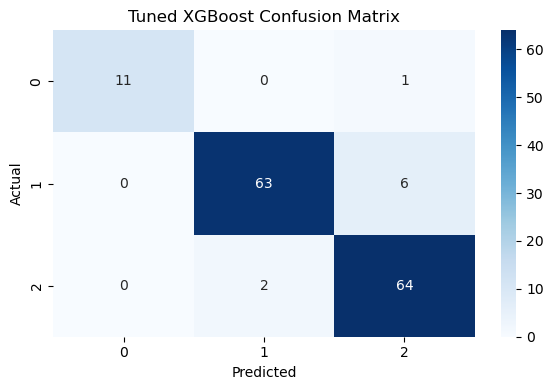

In [ ]:
# Tuned XGBoost Confusion Matrix Analysis
# Rows represent Actual Values.
# Columns represent Predicted Values.
cm = confusion_matrix(y_test, tuned_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Tuned XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 7. Predict Next Week Hospital Pressure using XGBoost Regression

For next-week prediction, we use `Hospital Pressure Score` as a continuous target. Lag features are created from previous pressure scores, then XGBoost Regressor predicts future pressure score values.

In [19]:
forecast_df = df.copy()

forecast_df["Date"] = pd.to_datetime(forecast_df["Date"])
forecast_df = forecast_df.sort_values("Date")

forecast_df["Pressure_Lag_1"] = forecast_df["Hospital Pressure Score"].shift(1)
forecast_df["Pressure_Lag_7"] = forecast_df["Hospital Pressure Score"].shift(7)
forecast_df["Pressure_Rolling_7"] = forecast_df["Hospital Pressure Score"].rolling(window=7).mean()

forecast_df = forecast_df.dropna().reset_index(drop=True)
forecast_df.head()

,Date,Patients,Emergency Cases,Available Beds,Occupied Beds,Total Nurses Required,Total Doctors Required,Nurses Available,Doctors Available,Medicine Usage,Weather,Festival,Day Type,Season,Hospital Pressure Score,Pressure Level,Pressure_Lag_1,Pressure_Lag_7,Pressure_Rolling_7
0,2024-01-08,268,34,563,80,14,8,11,8,656,Cloudy,No,Weekday,Winter,36.99,Low,30.50,31.49,35.182857
1,2024-01-09,233,22,563,80,17,7,14,7,616,Cloudy,No,Weekday,Winter,29.80,Low,36.99,32.69,34.770000
2,2024-01-10,259,28,563,80,14,8,11,8,746,Normal,No,Weekday,Winter,37.86,Low,29.80,34.59,35.237143
3,2024-01-11,255,26,563,86,16,7,14,7,585,Cloudy,No,Weekday,Winter,33.46,Low,37.86,33.54,35.225714
4,2024-01-12,235,28,563,80,17,7,14,5,560,Cloudy,No,Weekday,Winter,36.62,Low,33.46,30.65,36.078571


In [20]:
forecast_features = [
    "Patients",
    "Emergency Cases",
    "Available Beds",
    "Occupied Beds",
    "Total Nurses Required",
    "Total Doctors Required",
    "Nurses Available",
    "Doctors Available",
    "Medicine Usage",
    "Pressure_Lag_1",
    "Pressure_Lag_7",
    "Pressure_Rolling_7"
]

X_forecast = forecast_df[forecast_features]
y_forecast = forecast_df["Hospital Pressure Score"]

split_index = int(len(forecast_df) * 0.8)

X_train_f = X_forecast.iloc[:split_index]
X_test_f = X_forecast.iloc[split_index:]
y_train_f = y_forecast.iloc[:split_index]
y_test_f = y_forecast.iloc[split_index:]

dates_test = forecast_df["Date"].iloc[split_index:]

In [ ]:
# Forecasting Model Evaluation
# The XGBoost Regression model was evaluated using mean_absolute_error,RMSE,r2_score.
xgb_regressor = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    random_state=42
)

xgb_regressor.fit(X_train_f, y_train_f)

forecast_pred = xgb_regressor.predict(X_test_f)

mae = mean_absolute_error(y_test_f, forecast_pred)
rmse = np.sqrt(mean_squared_error(y_test_f, forecast_pred))
r2 = r2_score(y_test_f, forecast_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2.15187565823259
RMSE: 2.6706703385654786
R2 Score: 0.9609049819042363


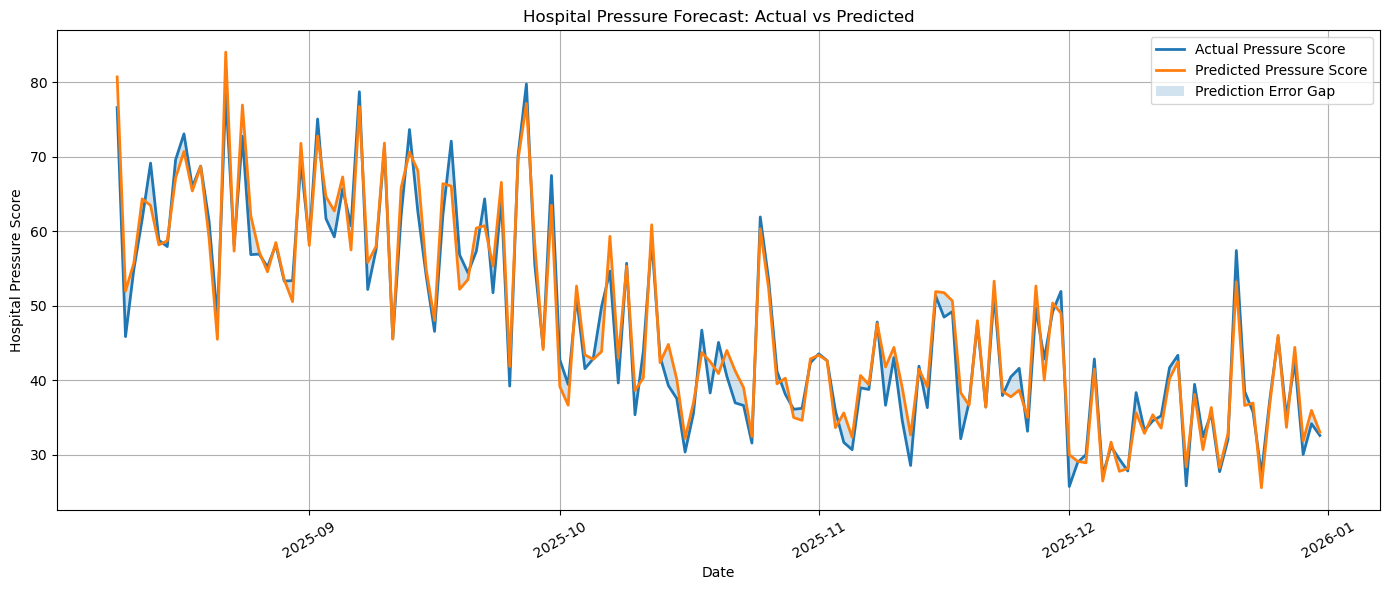

In [ ]:
# Forecast Graph Explanation
# This graph compares the actual hospital pressure score with the predicted pressure score.
plt.figure(figsize=(14,6))

plt.plot(dates_test, y_test_f.values, label="Actual Pressure Score", linewidth=2)
plt.plot(dates_test, forecast_pred, label="Predicted Pressure Score", linewidth=2)

plt.fill_between(
    dates_test,
    y_test_f.values,
    forecast_pred,
    alpha=0.2,
    label="Prediction Error Gap"
)

plt.title("Hospital Pressure Forecast: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Hospital Pressure Score")
plt.legend()
plt.xticks(rotation=30)
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
# Predict the next 7 days using the latest available hospital values.
# Assumption: patient/beds/staff/medicine values remain similar to the latest row.

future_predictions = []
forecast_history = forecast_df.copy()
last_known_date = forecast_history["Date"].max()

for i in range(1, 8):
    latest_row = forecast_history.iloc[-1].copy()
    next_date = last_known_date + pd.Timedelta(days=i)

    pressure_lag_1 = forecast_history["Hospital Pressure Score"].iloc[-1]
    pressure_lag_7 = forecast_history["Hospital Pressure Score"].iloc[-7]
    pressure_rolling_7 = forecast_history["Hospital Pressure Score"].tail(7).mean()

    next_features = pd.DataFrame([{
        "Patients": latest_row["Patients"],
        "Emergency Cases": latest_row["Emergency Cases"],
        "Available Beds": latest_row["Available Beds"],
        "Occupied Beds": latest_row["Occupied Beds"],
        "Total Nurses Required": latest_row["Total Nurses Required"],
        "Total Doctors Required": latest_row["Total Doctors Required"],
        "Nurses Available": latest_row["Nurses Available"],
        "Doctors Available": latest_row["Doctors Available"],
        "Medicine Usage": latest_row["Medicine Usage"],
        "Pressure_Lag_1": pressure_lag_1,
        "Pressure_Lag_7": pressure_lag_7,
        "Pressure_Rolling_7": pressure_rolling_7
    }])

    predicted_score = xgb_regressor.predict(next_features)[0]

    future_predictions.append({
        "Date": next_date,
        "Predicted Hospital Pressure Score": predicted_score
    })

    new_row = latest_row.copy()
    new_row["Date"] = next_date
    new_row["Hospital Pressure Score"] = predicted_score
    forecast_history = pd.concat([forecast_history, pd.DataFrame([new_row])], ignore_index=True)

future_df = pd.DataFrame(future_predictions)
future_df

,Date,Predicted Hospital Pressure Score
0,2026-01-01,31.280796
1,2026-01-02,30.012953
2,2026-01-03,30.926025
3,2026-01-04,30.620495
4,2026-01-05,30.241156
5,2026-01-06,29.506344
6,2026-01-07,29.534517


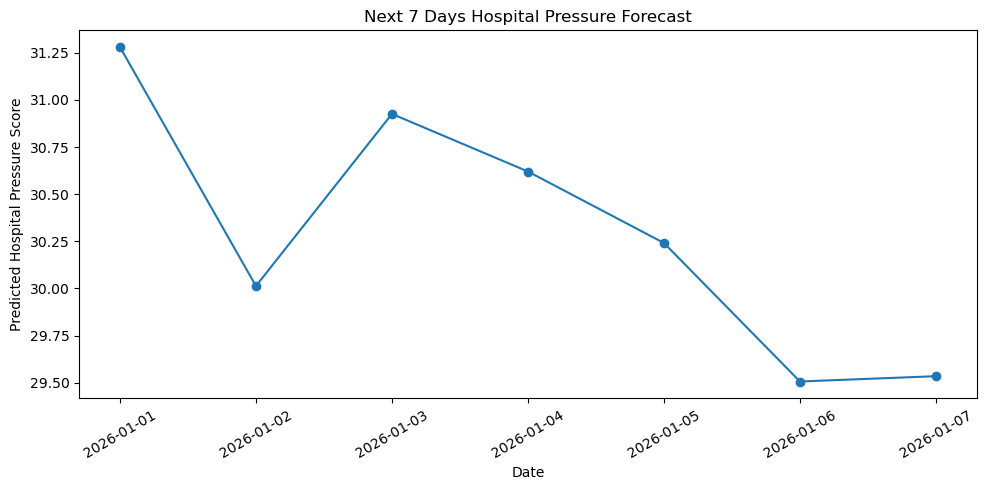

In [ ]:
# Graph Interpretation: Next 7 Days Hospital Pressure Forecast
# This graph shows the predicted hospital pressure score for the next 7 days using the trained XGBoost Regression model.
plt.figure(figsize=(10, 5))
plt.plot(future_df["Date"], future_df["Predicted Hospital Pressure Score"], marker="o")
plt.title("Next 7 Days Hospital Pressure Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Hospital Pressure Score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Final Conclusion

## Conclusion

In this project, multiple machine learning models were developed and compared to predict hospital pressure levels. The models evaluated were Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost.

The experimental results showed that Logistic Regression and Random Forest achieved the highest classification accuracy of approximately 93.2%, while Decision Tree produced the lowest accuracy of 86.4%.

Among all models, Random Forest was selected as the final model because it combines high predictive accuracy with strong generalization capability. Unlike a single Decision Tree, Random Forest uses multiple trees and aggregates their predictions, reducing overfitting and improving reliability. In addition, Random Forest can identify the most influential hospital factors through feature importance analysis, making the model more interpretable for healthcare management.

The study demonstrates that machine learning can effectively predict hospital pressure levels using operational hospital data. Such predictions can help hospital administrators allocate staff, beds, and medical resources more efficiently and prepare for periods of increased demand. Furthermore, the forecasting component can provide early warnings about future hospital pressure, supporting proactive decision-making and resource planning.
